# 📊 Evaluación — HybridCNN Audio Classifier

Carga el modelo entrenado usando **el mismo pipeline que `inference_test.ipynb`** (autodetección de modo, sin hardcodear `mel_only` / `mel_mfcc`) y evalúa sobre el split `test` del dataset procesado.

Produce:
- Accuracy, F1 macro y reporte por clase
- Matriz de confusión con valores absolutos y normalizada
- Guardado automático de ambas figuras en `FINAL_MODEL_DIR`

## 1 · Importaciones

In [1]:
from __future__ import annotations

import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
)
from tqdm import tqdm

warnings.filterwarnings("ignore")

from src.utils.config import (
    PROCESSED_METADATA,
    LABEL_MAPPING,
    FINAL_MODEL_DIR,
    CHECKPOINT_DIR,
)
from src.models.hybrid_cnn_v3 import ImprovedMFCCCNN
from src.models.audio_dataset import ProcessedAudioDataset, crnn_collate_fn

print("✅ Importaciones completadas")

✅ Importaciones completadas


## 2 · Configuración

In [2]:
# ─────────────────────────────────────────────
# 🔧 RUTAS — igual que inference_test.ipynb
# ─────────────────────────────────────────────
MODEL_PATH = FINAL_MODEL_DIR / "best_human_label_v6.pt"
# MODEL_PATH = CHECKPOINT_DIR / "checkpoint_epoch_16.pt"   # ← descomenta si usas checkpoint
# MODEL_PATH = FINAL_MODEL_DIR / "modelV4_32.pt"   # ← descomenta si usas checkpoint

LABEL_MAPPING_PATH = LABEL_MAPPING["human_label2"]
TARGET_TYPE        = "human_label"

# ─────────────────────────────────────────────
# 🖥️ DATALOADER
# ─────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 4
DROPOUT     = 0.25
PROCESSED_METADATA=PROCESSED_METADATA["2"]
# ─────────────────────────────────────────────
# 📊 VISUALIZACIÓN
# ─────────────────────────────────────────────
FIG_SIZE       = (16, 13)   # tamaño de la figura de la matriz
ANNOT_ABSOLUTE = True       # mostrar números en la matriz absoluta
ANNOT_NORM     = True       # mostrar porcentajes en la normalizada

print(f"📦 Modelo       : {MODEL_PATH}")
print(f"🗂️  Label mapping : {LABEL_MAPPING_PATH}")
print(f"📋 Metadata CSV : {PROCESSED_METADATA}")

📦 Modelo       : /home/andres/Documentos/proyecto4geeks/models/final/best_human_label_v6.pt
🗂️  Label mapping : /home/andres/Documentos/proyecto4geeks/data/interim/processed_dataset/label_mapping_human_labelV2.pkl
📋 Metadata CSV : /home/andres/Documentos/proyecto4geeks/data/interim/processed_dataset/processed_metadataV2.csv


## 3 · Device

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device_name = (
    torch.cuda.get_device_name(0)
    if device.type == "cuda"
    else "CPU"
)
print(f"🖥️  Dispositivo: {device} — {device_name}")

🖥️  Dispositivo: cuda — AMD Radeon RX 7600 XT


## 4 · Dataset y DataLoader de test

In [4]:
# ── Train dataset solo para heredar target_frames ────────────────────────────
# ProcessedAudioDataset infiere target_frames del primer .npy disponible.
# Usamos el split train como referencia para garantizar consistencia,
# igual que en 04_evaluation.ipynb original.
train_ds = ProcessedAudioDataset(
    metadata_csv=PROCESSED_METADATA,
    label_mapping_path=LABEL_MAPPING_PATH,
    split="train",
    target_column=TARGET_TYPE,
    use_mfcc=True,
    use_waveform=True,   # ← necesario para modo mel_waveform
    use_scalars=False,
)

# ── Test dataset ──────────────────────────────────────────────────────────────
test_ds = ProcessedAudioDataset(
    metadata_csv=PROCESSED_METADATA,
    label_mapping_path=LABEL_MAPPING_PATH,
    split="test",
    target_column=TARGET_TYPE,
    use_mfcc=True,
    use_waveform=True,   # ← necesario para modo mel_waveform
    use_scalars=False,
    target_frames=train_ds.target_frames,   # 🔥 CLAVE: mismos frames que train
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=crnn_collate_fn,
)

# Nombres de clases ordenados por índice
# label_mapping es {label: idx}, necesitamos {idx: label}
class_names = [k for k, v in sorted(test_ds.label_mapping.items(), key=lambda x: x[1])]
NUM_CLASSES = len(class_names)

print(f"✅ Test set      : {len(test_ds):,} muestras")
print(f"   Clases ({NUM_CLASSES})  : {class_names}")
print(f"   Target frames : {test_ds.target_frames}")


✅ Test set      : 1,760 muestras
   Clases (10)  : ['car_crash', 'construction_noise', 'crying', 'dog', 'fight', 'fire', 'glass_breaking', 'gun_explosion', 'siren_alarm', 'traffic']
   Target frames : 301


## 5 · Cargar modelo (autodetección de modo — igual que `inference_test.ipynb`)

In [5]:
def detect_mode_from_state_dict(state_dict: dict) -> str:
    keys = set(state_dict.keys())
    has_mel      = any(k.startswith("cnn_mel.")      for k in keys)
    has_mfcc     = any(k.startswith("cnn_mfcc.")     for k in keys)
    has_waveform = any(k.startswith("cnn_wave.") for k in keys)

    if has_mel and has_waveform:
        return "mel_waveform"
    elif has_mel and has_mfcc:
        return "mel_mfcc"
    elif has_mel:
        return "mel_only"
    elif has_mfcc:
        return "mfcc_only"
    else:
        raise ValueError("No se encontraron keys cnn_mel.*, cnn_mfcc.* ni waveform_cnn.* en el state_dict.")


def load_model(model_path: Path, num_classes: int, dropout: float) -> tuple[ImprovedMFCCCNN, str]:
    checkpoint = torch.load(model_path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        state_dict = checkpoint["model_state"]
        epoch_info = checkpoint.get("epoch", "?")
        acc_info   = checkpoint.get("best_acc", "?")
        print(f"   📌 Checkpoint — epoch: {epoch_info}  |  best_acc: {acc_info}")
    else:
        state_dict = checkpoint

    detected_mode = detect_mode_from_state_dict(state_dict)
    print(f"   🔍 Modo detectado automáticamente: {detected_mode}")

    model = ImprovedMFCCCNN(num_classes=num_classes, dropout=dropout, mode=detected_mode).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    return model, detected_mode


model, MODE = load_model(MODEL_PATH, NUM_CLASSES, DROPOUT)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modelo cargado  |  {total_params:,} parámetros  |  modo: {MODE}")

   🔍 Modo detectado automáticamente: mel_waveform
✅ Modelo cargado  |  1,842,580 parámetros  |  modo: mel_waveform


## 6 · Inferencia sobre el split test

In [6]:
def prepare_inputs(batch: dict, device, mode: str):
    """Prepara los tensores de entrada según el modo del modelo."""
    mel      = batch.get("mel",      None)
    mfcc     = batch.get("mfcc",     None)
    waveform = batch.get("waveform", None)

    if mel      is not None: mel      = mel.to(device)
    if mfcc     is not None: mfcc     = mfcc.to(device)
    if waveform is not None: waveform = waveform.to(device)

    if mode == "mel_only":
        return {"mel": mel}
    elif mode == "mfcc_only":
        return {"mel": mel, "mfcc": mfcc}   # mel ignorado internamente
    elif mode == "mel_waveform":
        return {"mel": mel, "waveform": waveform}
    else:  # mel_mfcc
        return {"mel": mel, "mfcc": mfcc}


@torch.no_grad()
def run_inference(model, loader, device, mode) -> tuple[list, list]:
    model.eval()
    y_true, y_pred = [], []

    for batch, labels, _ in tqdm(loader, desc="Evaluando"):
        labels = labels.to(device)
        kwargs = prepare_inputs(batch, device, mode)
        logits = model(**kwargs)
        preds  = logits.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred


y_true, y_pred = run_inference(model, test_loader, device, MODE)

acc    = accuracy_score(y_true, y_pred)
f1_mac = f1_score(y_true, y_pred, average="macro",  zero_division=0)
f1_wt  = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"\n📊 Accuracy     : {acc:.4f}  ({acc:.2%})")
print(f"   F1 macro     : {f1_mac:.4f}")
print(f"   F1 weighted  : {f1_wt:.4f}")


Evaluando: 100%|██████████| 55/55 [00:04<00:00, 12.22it/s]


📊 Accuracy     : 0.7977  (79.77%)
   F1 macro     : 0.7960
   F1 weighted  : 0.7960


## 7 · Reporte por clase

In [7]:
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    zero_division=0,
    digits=3,
)
print(report)

                    precision    recall  f1-score   support

         car_crash      0.864     0.864     0.864       176
construction_noise      0.856     0.812     0.834       176
            crying      0.766     0.875     0.817       176
               dog      0.912     0.881     0.896       176
             fight      0.962     0.852     0.904       176
              fire      0.806     0.472     0.595       176
    glass_breaking      0.887     0.847     0.866       176
     gun_explosion      0.796     0.955     0.868       176
       siren_alarm      0.662     0.756     0.706       176
           traffic      0.565     0.665     0.611       176

          accuracy                          0.798      1760
         macro avg      0.808     0.798     0.796      1760
      weighted avg      0.808     0.798     0.796      1760



## 8 · Matriz de confusión — valores absolutos

✅ Guardada en: /home/andres/Documentos/proyecto4geeks/models/final/confusion_matrix_absolute.png


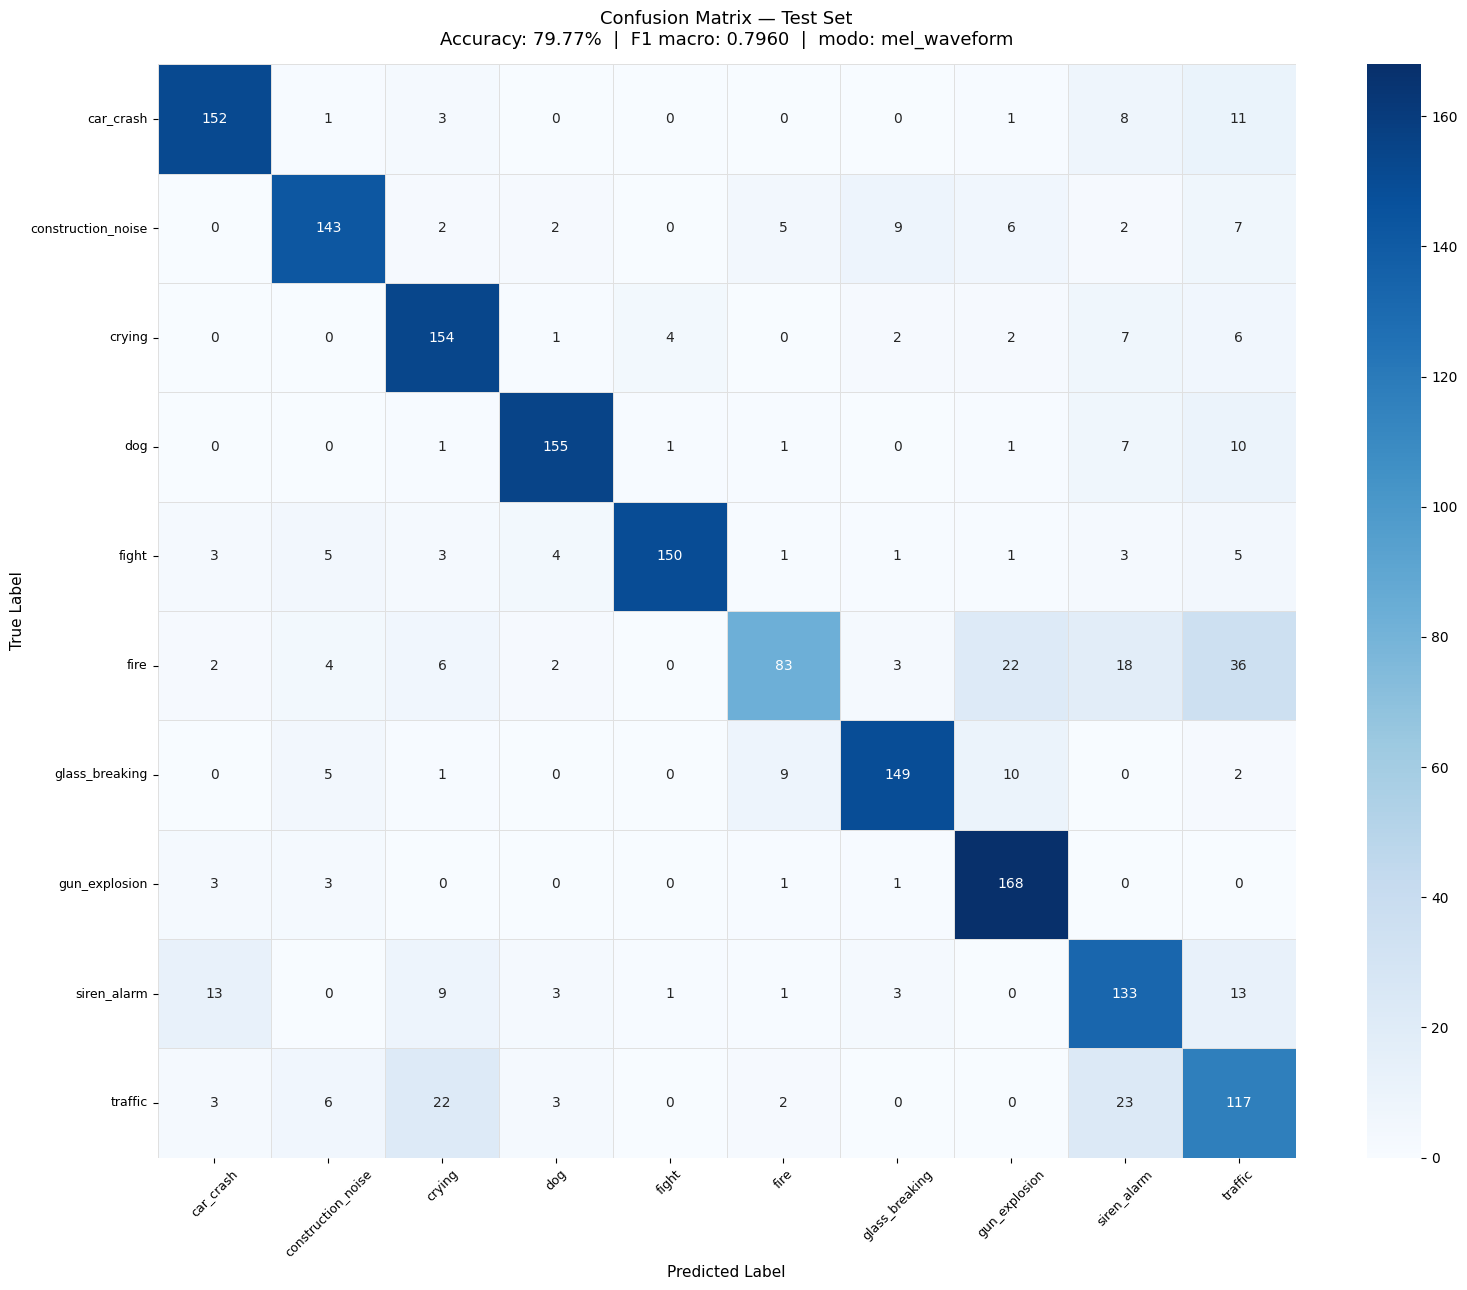

In [8]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.heatmap(
    cm,
    annot=ANNOT_ABSOLUTE,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="#e0e0e0",
    ax=ax,
)

ax.set_title(
    f"Confusion Matrix — Test Set\nAccuracy: {acc:.2%}  |  F1 macro: {f1_mac:.4f}  |  modo: {MODE}",
    fontsize=13, pad=14,
)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label",      fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()

save_path = FINAL_MODEL_DIR / "confusion_matrix_absolute.png"
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)
fig.savefig(save_path, dpi=180, bbox_inches="tight")
print(f"✅ Guardada en: {save_path}")

plt.show()

## 9 · Matriz de confusión — normalizada por fila (recall por clase)

✅ Guardada en: /home/andres/Documentos/proyecto4geeks/models/final/confusion_matrix_normalized.png


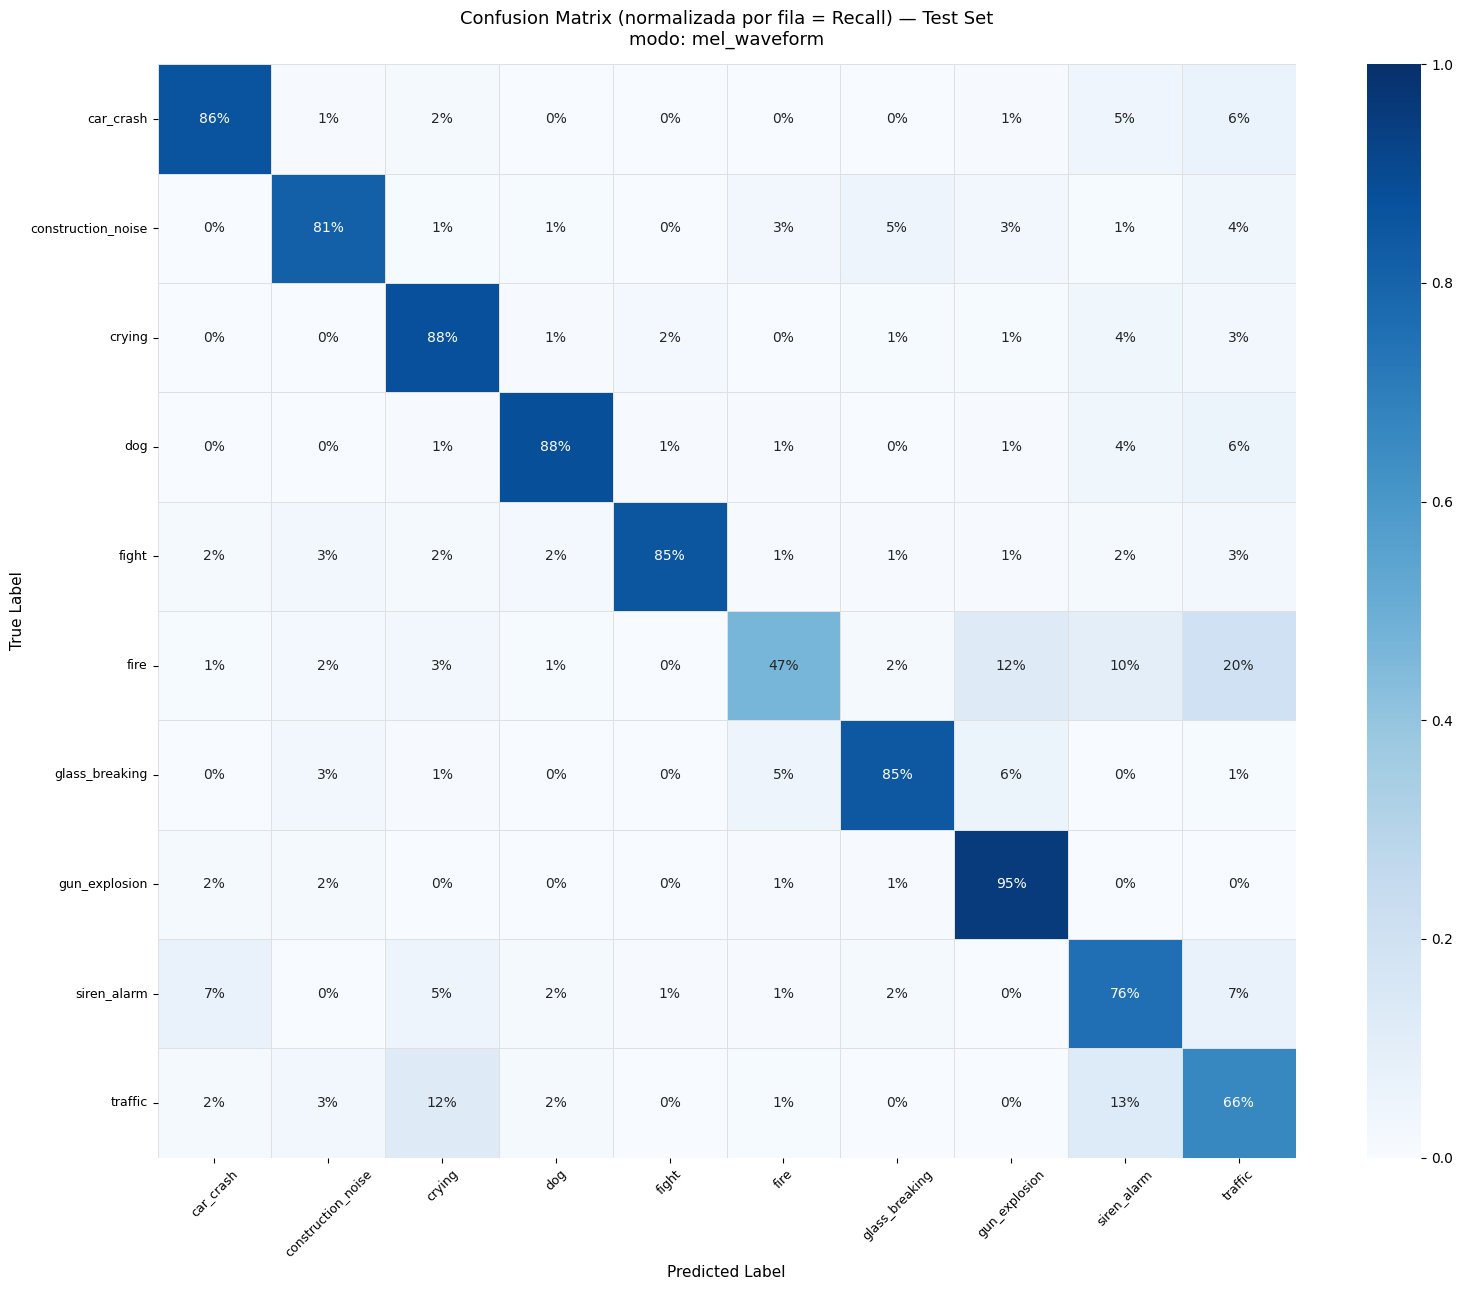

In [9]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=FIG_SIZE)

annot_data = (
    np.array([[f"{v:.0%}" for v in row] for row in cm_norm])
    if ANNOT_NORM else False
)

sns.heatmap(
    cm_norm,
    annot=annot_data if ANNOT_NORM else False,
    fmt="",
    cmap="Blues",
    vmin=0, vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="#e0e0e0",
    ax=ax,
)

ax.set_title(
    f"Confusion Matrix (normalizada por fila = Recall) — Test Set\nmodo: {MODE}",
    fontsize=13, pad=14,
)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label",      fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()

save_path_norm = FINAL_MODEL_DIR / "confusion_matrix_normalized.png"
fig.savefig(save_path_norm, dpi=180, bbox_inches="tight")
print(f"✅ Guardada en: {save_path_norm}")

plt.show()

## 10 · Clases con más errores

📉 Clases ordenadas por recall (peor → mejor):


,Clase,Recall,Muestras test
0,fire,47.16%,176
1,traffic,66.48%,176
2,siren_alarm,75.57%,176
3,construction_noise,81.25%,176
4,glass_breaking,84.66%,176
5,fight,85.23%,176
6,car_crash,86.36%,176
7,crying,87.50%,176
8,dog,88.07%,176
9,gun_explosion,95.45%,176



✅ Guardado en: /home/andres/Documentos/proyecto4geeks/models/final/recall_per_class.png


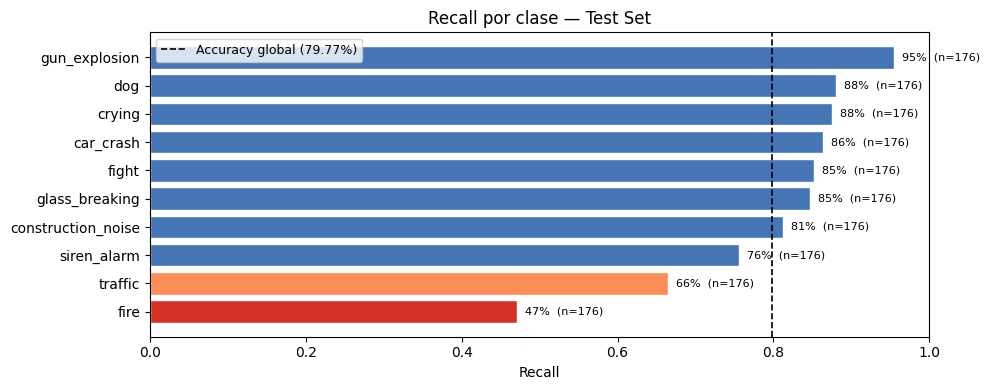

In [10]:
import pandas as pd

# Recall por clase (diagonal / total real de esa clase)
per_class_recall = cm.diagonal() / cm.sum(axis=1).clip(min=1)

# Cuántas muestras reales tiene cada clase
support = cm.sum(axis=1)

df_perf = (
    pd.DataFrame({
        "class":   class_names,
        "recall":  per_class_recall,
        "support": support,
    })
    .sort_values("recall")
    .reset_index(drop=True)
)

df_perf["recall_fmt"] = df_perf["recall"].map("{:.2%}".format)

print("📉 Clases ordenadas por recall (peor → mejor):")
display(df_perf[["class", "recall_fmt", "support"]].rename(
    columns={"class": "Clase", "recall_fmt": "Recall", "support": "Muestras test"}
))

# ── Barplot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(4, NUM_CLASSES * 0.38)))

colors = ["#d73027" if r < 0.5 else "#fc8d59" if r < 0.7 else "#4575b4"
          for r in df_perf["recall"]]

ax.barh(df_perf["class"], df_perf["recall"], color=colors, edgecolor="white")
ax.axvline(x=acc, color="black", linestyle="--", linewidth=1.2, label=f"Accuracy global ({acc:.2%})")
ax.set_xlim(0, 1)
ax.set_xlabel("Recall")
ax.set_title("Recall por clase — Test Set")
ax.legend(fontsize=9)

for i, (r, sup) in enumerate(zip(df_perf["recall"], df_perf["support"])):
    ax.text(min(r + 0.01, 0.97), i, f"{r:.0%}  (n={sup})", va="center", fontsize=8)

plt.tight_layout()

save_path_bar = FINAL_MODEL_DIR / "recall_per_class.png"
fig.savefig(save_path_bar, dpi=150, bbox_inches="tight")
print(f"\n✅ Guardado en: {save_path_bar}")

plt.show()

## 11 · Confusiones más frecuentes (top errores)

In [11]:
# Extraer pares (real, predicho) con más confusiones (fuera de la diagonal)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

pairs = [
    {
        "true":      class_names[i],
        "predicted": class_names[j],
        "count":     cm_off[i, j],
        "recall_true": f"{per_class_recall[i]:.0%}",
    }
    for i in range(NUM_CLASSES)
    for j in range(NUM_CLASSES)
    if cm_off[i, j] > 0
]

df_errors = (
    pd.DataFrame(pairs)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
    .head(20)
)

print("⚠️  Top-20 confusiones (real → predicho):")
display(df_errors)

⚠️  Top-20 confusiones (real → predicho):


,true,predicted,count,recall_true
0,fire,traffic,36,47%
1,traffic,siren_alarm,23,66%
2,traffic,crying,22,66%
3,fire,gun_explosion,22,47%
4,fire,siren_alarm,18,47%
5,siren_alarm,car_crash,13,76%
6,siren_alarm,traffic,13,76%
7,car_crash,traffic,11,86%
8,glass_breaking,gun_explosion,10,85%
9,dog,traffic,10,88%
